In [2]:
import numpy as np
import pandas as pd
import os

np.random.seed(42)  

n = 200
normal_values = np.random.normal(loc=50, scale=10, size=n-5)
outliers = np.array([150, 160, -30, 145, -20])   # deliberately extreme
values = np.concatenate([normal_values, outliers])
np.random.shuffle(values)

df = pd.DataFrame({
    'id': range(len(values)),
    'value': values,
    'predictor': np.random.normal(loc=20, scale=5, size=len(values))
})

os.makedirs('data/raw', exist_ok=True)
df.to_csv('data/raw/stage07_data.csv', index=False)
df.head()

,id,value,predictor
0,0,52.598828,21.926587
1,1,57.384666,24.127082
2,2,59.633761,24.067548
3,3,53.312634,26.527394
4,4,41.841897,20.105019


In [3]:
def detect_outliers_iqr(series, k=1.5):
   
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series, threshold=3.0):
  
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

def winsorize_series(series, lower=0.05, upper=0.95):
   
    lo_val = series.quantile(lower)
    hi_val = series.quantile(upper)
    return series.clip(lower=lo_val, upper=hi_val)

In [4]:
df['is_outlier_iqr'] = detect_outliers_iqr(df['value'])
df['is_outlier_zscore'] = detect_outliers_zscore(df['value'])

print("IQR method flagged:", df['is_outlier_iqr'].sum(), "outliers")
print("Z-score method flagged:", df['is_outlier_zscore'].sum(), "outliers")

IQR method flagged: 8 outliers
Z-score method flagged: 5 outliers


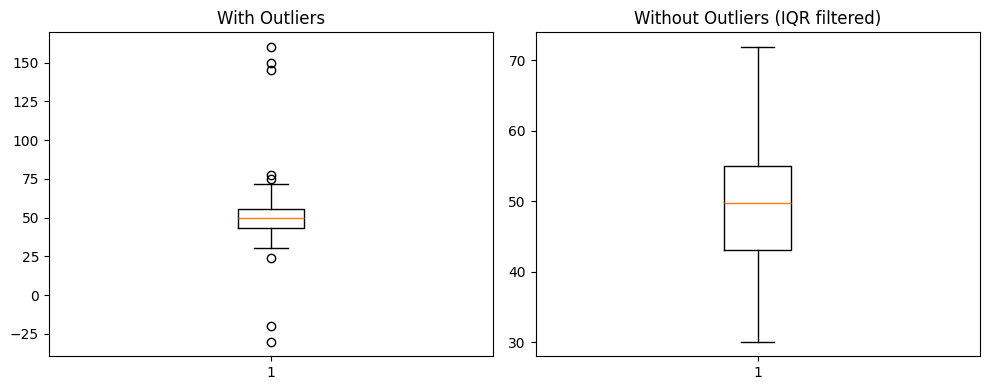

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['value'])
axes[0].set_title('With Outliers')
axes[1].boxplot(df.loc[~df['is_outlier_iqr'], 'value'])
axes[1].set_title('Without Outliers (IQR filtered)')
plt.tight_layout()
plt.show()

In [6]:
all_data = df['value']
filtered_data = df.loc[~df['is_outlier_iqr'], 'value']
winsorized_data = winsorize_series(df['value'])

summary = pd.DataFrame({
    'all': [all_data.mean(), all_data.median(), all_data.std()],
    'filtered (IQR)': [filtered_data.mean(), filtered_data.median(), filtered_data.std()],
    'winsorized': [winsorized_data.mean(), winsorized_data.median(), winsorized_data.std()],
}, index=['mean', 'median', 'std'])
summary

,all,filtered (IQR),winsorized
mean,50.438769,49.516235,49.714429
median,49.958081,49.799944,49.958081
std,17.283059,8.855353,8.879507


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

def fit_and_score(data):
    X = data[['predictor']]
    y = data['value']
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    return {
        'coef': model.coef_[0],
        'r2': r2_score(y, preds),
        'mae': mean_absolute_error(y, preds)
    }

results = {
    'all': fit_and_score(df),
    'filtered': fit_and_score(df.loc[~df['is_outlier_iqr']]),
    'winsorized': fit_and_score(pd.DataFrame({'predictor': df['predictor'], 'value': winsorized_data}))
}
pd.DataFrame(results).T

,coef,r2,mae
all,-0.016918,0.000023,9.550424
filtered,0.078332,0.001878,7.153125
winsorized,0.067966,0.001433,7.308970
